Taller: Detección de Bordes y Contornos
Curso: Computación Visual
Entorno: Python (OpenCV, scikit-image, numpy, matplotlib)
Descripción: Implementación completa de operadores de bordes, detección de contornos,
             aproximación de formas, análisis de momentos y sistema de inspección.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, feature
import os

# Crear carpeta media si no existe


In [2]:
os.makedirs("media", exist_ok=True)



# 1. Carga y preparación de imagen de prueba (sintética con formas geométricas)


In [3]:
def crear_imagen_prueba():
    """Crea una imagen sintética con diferentes formas para pruebas."""
    img = np.zeros((500, 500, 3), dtype=np.uint8)
    # Fondo blanco
    img.fill(255)
    # Dibujar rectángulo
    cv2.rectangle(img, (50, 50), (200, 150), (0, 0, 0), -1)
    # Dibujar círculo
    cv2.circle(img, (350, 100), 50, (0, 0, 0), -1)
    # Dibujar triángulo
    pts = np.array([[250, 350], [150, 450], [350, 450]], np.int32)
    cv2.fillPoly(img, [pts], (0, 0, 0))
    # Dibujar pentágono
    pts = np.array([[400, 300], [450, 350], [430, 420], [370, 420], [350, 350]], np.int32)
    cv2.fillPoly(img, [pts], (0, 0, 0))
    # Ruido leve
    noise = np.random.randint(0, 30, img.shape, dtype=np.uint8)
    img = cv2.addWeighted(img, 0.9, noise, 0.1, 0)
    return img

img_color = crear_imagen_prueba()
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
cv2.imwrite("media/imagen_original.png", img_color)


True

# 2. Operadores básicos de detección de bordes


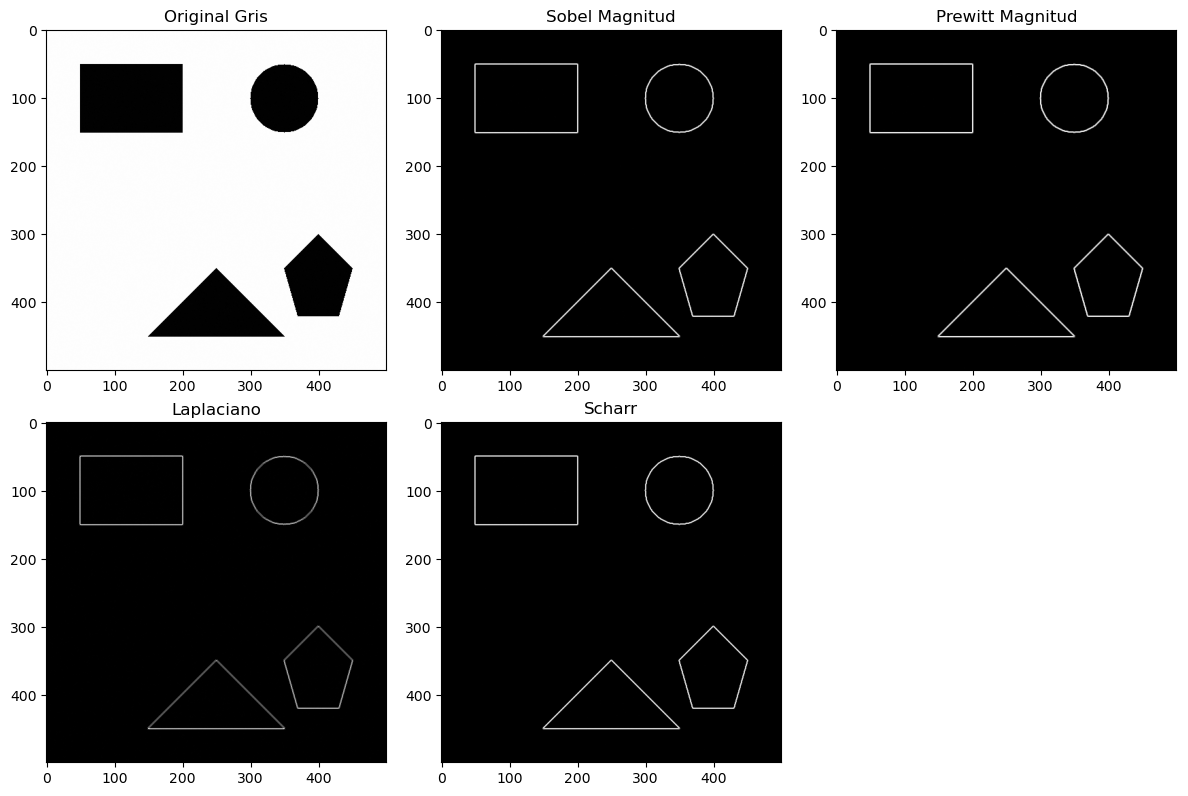

In [4]:
def aplicar_sobel(img):
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.hypot(sobel_x, sobel_y)
    sobel_mag = np.uint8(255 * sobel_mag / np.max(sobel_mag))
    return sobel_x, sobel_y, sobel_mag

def aplicar_prewitt(img):
    # Prewitt usando scikit-image
    prewitt_x = filters.prewitt_h(img)
    prewitt_y = filters.prewitt_v(img)
    prewitt_mag = np.hypot(prewitt_x, prewitt_y)
    prewitt_mag = np.uint8(255 * prewitt_mag / np.max(prewitt_mag))
    return prewitt_x, prewitt_y, prewitt_mag

def aplicar_laplaciano(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
    laplacian = np.uint8(255 * np.abs(laplacian) / np.max(np.abs(laplacian)))
    return laplacian

def aplicar_scharr(img):
    scharr_x = cv2.Scharr(img, cv2.CV_64F, 1, 0)
    scharr_y = cv2.Scharr(img, cv2.CV_64F, 0, 1)
    scharr_mag = np.hypot(scharr_x, scharr_y)
    scharr_mag = np.uint8(255 * scharr_mag / np.max(scharr_mag))
    return scharr_x, scharr_y, scharr_mag

# Aplicar operadores
sobel_x, sobel_y, sobel_mag = aplicar_sobel(img_gray)
prewitt_x, prewitt_y, prewitt_mag = aplicar_prewitt(img_gray)
laplaciano = aplicar_laplaciano(img_gray)
scharr_x, scharr_y, scharr_mag = aplicar_scharr(img_gray)

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0,0].imshow(img_gray, cmap='gray')
axes[0,0].set_title('Original Gris')
axes[0,1].imshow(sobel_mag, cmap='gray')
axes[0,1].set_title('Sobel Magnitud')
axes[0,2].imshow(prewitt_mag, cmap='gray')
axes[0,2].set_title('Prewitt Magnitud')
axes[1,0].imshow(laplaciano, cmap='gray')
axes[1,0].set_title('Laplaciano')
axes[1,1].imshow(scharr_mag, cmap='gray')
axes[1,1].set_title('Scharr')
axes[1,2].axis('off')
plt.tight_layout()
plt.savefig("media/operadores_bordes.png")
plt.show()

# 3. Detector Canny con experimentación de parámetros


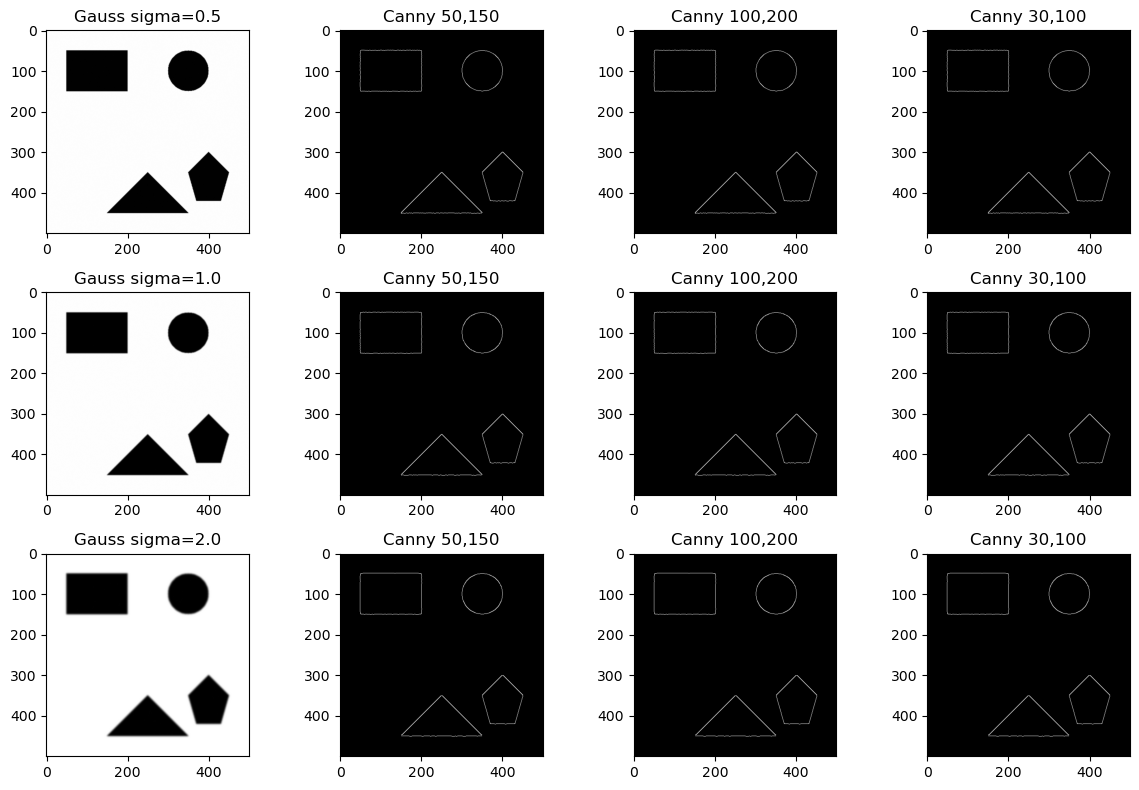

True

In [5]:
def experimentar_canny(img):
    # Aplicar suavizado Gaussiano con diferentes sigmas
    sigmas = [0.5, 1.0, 2.0]
    umbrales = [(50, 150), (100, 200), (30, 100)]

    fig, axes = plt.subplots(len(sigmas), len(umbrales)+1, figsize=(12, 8))
    for i, sigma in enumerate(sigmas):
        blurred = cv2.GaussianBlur(img, (0,0), sigma)
        axes[i,0].imshow(blurred, cmap='gray')
        axes[i,0].set_title(f'Gauss sigma={sigma}')
        for j, (low, high) in enumerate(umbrales):
            edges = cv2.Canny(blurred, low, high)
            axes[i, j+1].imshow(edges, cmap='gray')
            axes[i, j+1].set_title(f'Canny {low},{high}')
    plt.tight_layout()
    plt.savefig("media/experimento_canny.png")
    plt.show()

    # Mejor combinación (ejemplo)
    mejor = cv2.GaussianBlur(img, (0,0), 1.0)
    mejor = cv2.Canny(mejor, 50, 150)
    return mejor

canny_edges = experimentar_canny(img_gray)
cv2.imwrite("media/canny_mejor.png", canny_edges)

# 4. Detección de contornos


In [6]:
def detectar_contornos(img_bin):
    # Umbral adaptativo para binarizar
    binaria = cv2.adaptiveThreshold(img_bin, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV, 11, 2)
    # Encontrar contornos (jerarquía completa)
    contornos, jerarquia = cv2.findContours(binaria, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Filtrar por área mínima
    area_min = 500
    contornos_filtrados = [c for c in contornos if cv2.contourArea(c) > area_min]
    return binaria, contornos_filtrados, jerarquia

binaria, contornos, _ = detectar_contornos(img_gray)

# Dibujar contornos sobre imagen original
img_contornos = img_color.copy()
cv2.drawContours(img_contornos, contornos, -1, (0, 255, 0), 2)
cv2.imwrite("media/contornos_detectados.png", img_contornos)

True

# 5. Aproximación de formas, perímetro, área y clasificación


In [7]:
def clasificar_forma(contorno):
    perimetro = cv2.arcLength(contorno, True)
    epsilon = 0.02 * perimetro
    aproximacion = cv2.approxPolyDP(contorno, epsilon, True)
    vertices = len(aproximacion)
    area = cv2.contourArea(contorno)

    if vertices == 3:
        forma = "Triangulo"
    elif vertices == 4:
        # Puede ser cuadrado o rectángulo, simplificamos
        forma = "Rectangulo"
    elif vertices > 4:
        # Ver si es círculo: relación área/perímetro
        circularidad = 4 * np.pi * area / (perimetro * perimetro)
        if circularidad > 0.8:
            forma = "Circulo"
        else:
            forma = f"Poligono_{vertices}"
    else:
        forma = "Desconocido"
    return forma, vertices, area, perimetro, aproximacion

# Clasificar cada contorno y dibujar centroides
img_formas = img_color.copy()
info_formas = []
for cnt in contornos:
    forma, vertices, area, perimetro, aprox = clasificar_forma(cnt)
    info_formas.append((forma, vertices, area, perimetro))
    # Dibujar aproximación poligonal
    cv2.drawContours(img_formas, [aprox], -1, (255, 0, 0), 3)
    # Calcular centroide
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.circle(img_formas, (cx, cy), 5, (0, 0, 255), -1)
        cv2.putText(img_formas, forma, (cx-30, cy-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

cv2.imwrite("media/clasificacion_formas.png", img_formas)
print("Información de formas encontradas:")
for i, info in enumerate(info_formas):
    print(f"  {i+1}: {info[0]} | vértices={info[1]} | área={info[2]:.1f} | perímetro={info[3]:.1f}")

Información de formas encontradas:
  1: Triangulo | vértices=3 | área=10000.0 | perímetro=482.8
  2: Triangulo | vértices=3 | área=8252.0 | perímetro=518.6
  3: Poligono_5 | vértices=5 | área=8100.0 | perímetro=358.0
  4: Poligono_5 | vértices=5 | área=6834.0 | perímetro=369.6
  5: Circulo | vértices=8 | área=7704.0 | perímetro=329.7
  6: Poligono_8 | vértices=8 | área=6557.5 | perímetro=330.1
  7: Rectangulo | vértices=4 | área=15000.0 | perímetro=500.0
  8: Rectangulo | vértices=4 | área=13208.0 | perímetro=554.5


# 6. Análisis de momentos: centroide, orientación, excentricidad


In [8]:
def analizar_momentos(contorno):
    M = cv2.moments(contorno)
    if M["m00"] == 0:
        return None
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    # Orientación (ángulo del eje principal)
    mu11 = M["mu11"]
    mu20 = M["mu20"]
    mu02 = M["mu02"]
    theta = 0.5 * np.arctan2(2*mu11, (mu20 - mu02))
    theta_deg = np.degrees(theta)

    # Excentricidad usando ajuste de elipse (solo si hay suficientes puntos)
    excentricidad = None
    if len(contorno) >= 5:
        try:
            ellipse = cv2.fitEllipse(contorno)
            (_, _), (MA, ma), _ = ellipse
            if MA > 0 and ma > 0:
                # Asegurar que MA >= ma
                if ma > MA:
                    MA, ma = ma, MA
                ratio = ma / MA
                if ratio > 1:
                    ratio = 1.0
                excentricidad = np.sqrt(1 - ratio*ratio)
        except:
            # Si falla el ajuste, se deja como None
            pass
    return cx, cy, theta_deg, excentricidad


print("\nAnálisis de momentos por contorno:")
for i, cnt in enumerate(contornos):
    datos = analizar_momentos(cnt)
    if datos:
        cx, cy, theta, exc = datos
        # Manejar None y NaN
        if exc is None or np.isnan(exc):
            exc_str = "N/A"
        else:
            exc_str = f"{exc:.3f}"
        print(f"  Contorno {i+1}: centro=({cx:.1f},{cy:.1f}) | orientación={theta:.1f}° | excentricidad={exc_str}")


Análisis de momentos por contorno:
  Contorno 1: centro=(250.0,416.7) | orientación=-0.0° | excentricidad=N/A
  Contorno 2: centro=(250.0,415.9) | orientación=-0.0° | excentricidad=0.825
  Contorno 3: centro=(400.0,367.0) | orientación=90.0° | excentricidad=0.774
  Contorno 4: centro=(400.0,367.1) | orientación=-90.0° | excentricidad=0.637
  Contorno 5: centro=(350.0,100.0) | orientación=90.0° | excentricidad=0.000
  Contorno 6: centro=(350.0,100.0) | orientación=15.9° | excentricidad=0.051
  Contorno 7: centro=(125.0,100.0) | orientación=0.0° | excentricidad=N/A
  Contorno 8: centro=(125.0,100.0) | orientación=0.2° | excentricidad=0.799


# 7. Aplicación de inspección (control de calidad)


In [9]:
def sistema_inspeccion(img, contornos, area_min=1000, area_max=10000):
    """Detecta defectos, cuenta objetos y clasifica por forma."""
    img_inspeccion = img.copy()
    conteo = {"Triangulo":0, "Rectangulo":0, "Circulo":0, "Otros":0}
    objetos_defectuosos = []

    for cnt in contornos:
        area = cv2.contourArea(cnt)
        forma, vertices, _, _, _ = clasificar_forma(cnt)

        # Clasificar por área (defecto si área fuera de rango)
        estado = "OK"
        if area < area_min:
            estado = "Defecto (muy pequeño)"
            objetos_defectuosos.append(("pequeño", area))
        elif area > area_max:
            estado = "Defecto (muy grande)"
            objetos_defectuosos.append(("grande", area))

        # Determinar tipo para conteo
        if forma in conteo:
            conteo[forma] += 1
        else:
            conteo["Otros"] += 1

        # Dibujar bounding box y texto
        x, y, w, h = cv2.boundingRect(cnt)
        color = (0,255,0) if estado=="OK" else (0,0,255)
        cv2.rectangle(img_inspeccion, (x,y), (x+w,y+h), color, 2)
        cv2.putText(img_inspeccion, f"{area:.0f}", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    cv2.imwrite("media/inspeccion_calidad.png", img_inspeccion)

    # Reporte de inspección
    print("\n=== REPORTE DE INSPECCIÓN ===")
    print(f"Total objetos detectados: {len(contornos)}")
    for k,v in conteo.items():
        print(f"  {k}: {v}")
    print(f"Objetos defectuosos: {len(objetos_defectuosos)}")
    for defecto in objetos_defectuosos:
        print(f"  - {defecto[0]} (área={defecto[1]:.1f})")
    return conteo, objetos_defectuosos

sistema_inspeccion(img_color, contornos, area_min=800, area_max=12000)


=== REPORTE DE INSPECCIÓN ===
Total objetos detectados: 8
  Triangulo: 2
  Rectangulo: 2
  Circulo: 1
  Otros: 3
Objetos defectuosos: 2
  - grande (área=15000.0)
  - grande (área=13208.0)


({'Triangulo': 2, 'Rectangulo': 2, 'Circulo': 1, 'Otros': 3},
 [('grande', 15000.0), ('grande', 13208.0)])

# 8. Bonus: Detección de esquinas (Harris y Shi-Tomasi)


In [10]:
def deteccion_esquinas(img_gray, img_color):
    # Harris
    dst = cv2.cornerHarris(img_gray, 2, 3, 0.04)
    dst = cv2.dilate(dst, None)
    img_harris = img_color.copy()
    img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

    # Shi-Tomasi (good features to track)
    esquinas = cv2.goodFeaturesToTrack(img_gray, maxCorners=50, qualityLevel=0.01, minDistance=10)
    img_shi = img_color.copy()
    if esquinas is not None:
        # Convertir a enteros usando np.int32 (o int)
        esquinas = np.int32(esquinas)
        for esquina in esquinas:
            x, y = esquina.ravel()
            cv2.circle(img_shi, (x, y), 5, (0, 255, 0), -1)

    cv2.imwrite("media/esquinas_harris.png", img_harris)
    cv2.imwrite("media/esquinas_shi_tomasi.png", img_shi)
    return img_harris, img_shi

# 9. Bonus: Medición de objetos con referencia de escala (simulado)


In [11]:
def medicion_con_escala(img, contornos, escala_pixel_a_mm=0.1):
    """
    Escala simulada: 1 píxel = 0.1 mm.
    Calcula dimensiones de cada objeto usando bounding box.
    """
    img_med = img.copy()
    for i, cnt in enumerate(contornos):
        x, y, w, h = cv2.boundingRect(cnt)
        ancho_mm = w * escala_pixel_a_mm
        alto_mm = h * escala_pixel_a_mm
        cv2.rectangle(img_med, (x,y), (x+w,y+h), (255,0,0), 2)
        cv2.putText(img_med, f"{ancho_mm:.1f}x{alto_mm:.1f}mm", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)
    cv2.imwrite("media/medicion_con_escala.png", img_med)
    print("\nMediciones simuladas (1 px = 0.1 mm): guardadas en media/medicion_con_escala.png")

medicion_con_escala(img_color, contornos, escala_pixel_a_mm=0.1)


Mediciones simuladas (1 px = 0.1 mm): guardadas en media/medicion_con_escala.png


# 10. Bonus: OCR simple usando contornos (detección de dígitos aislados)

In [12]:
def ocr_simple_contornos(img_gray):
    """
    Ejemplo conceptual: detectar regiones que podrían ser caracteres
    basado en relación de aspecto y área. (No implementa reconocimiento real)
    """
    _, thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []
    for cnt in contornos:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(cnt)
        # Heurística de caracteres (sin pretensiones de precisión)
        if 0.2 < aspect_ratio < 1.0 and 100 < area < 5000:
            candidatos.append((x, y, w, h))
    return candidatos

# Para demostración, se usa la imagen original; se esperan pocos candidatos
candidatos_ocr = ocr_simple_contornos(img_gray)
print(f"\nPosibles regiones de caracteres (simulación OCR): {len(candidatos_ocr)} encontradas")


Posibles regiones de caracteres (simulación OCR): 0 encontradas
